# Sistem za automatsko prepoznavanje registarskih tablica
---

## Instalacije

In [1]:
#!pip install kagglehub ultralytics easyocr opencv-python-headless
#!pip install matplotlib seaborn scikit-learn pandas numpy Pillow
#!pip install torch torchvision  jupyterlab
#!pip install lxml

## Importi

In [2]:
import os
import re
import glob
import random
import time
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Koristi se uređaj: {DEVICE}")
print(f" PyTorch verzija: {torch.__version__}")

 Koristi se uređaj: cuda
 PyTorch verzija: 2.14.0+cu126


# 3. Dataset i Preprocesiranje

## 3.1 Preuzimanje 

https://www.kaggle.com/datasets/andrewmvd/car-plate-detection

In [3]:
# Instalacija dataseta
#import kagglehub
#path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

#print("Path to dataset files:", path)

path = r"D:\UNI\2025-2026\Semestar II\MasinskoUcenje\dataset" 


IMAGE_DIR = os.path.join(path, 'images')
ANNOT_DIR = os.path.join(path, 'annotations')

image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))
annot_files = sorted(glob.glob(os.path.join(ANNOT_DIR, '*.xml')))

print(f"   Broj slika:      {len(image_files)}")
print(f"   Broj anotacija:  {len(annot_files)}")

   Broj slika:      433
   Broj anotacija:  433


## 3.2 Parsiranje XML Anotacija


In [4]:
def parse_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    boxes = []
    for obj in root.findall('object'):
        bndbox = obj.find('bndbox')
        xmin = int(float(bndbox.find('xmin').text))
        ymin = int(float(bndbox.find('ymin').text))
        xmax = int(float(bndbox.find('xmax').text))
        ymax = int(float(bndbox.find('ymax').text))
        boxes.append((xmin, ymin, xmax, ymax))
    
    return boxes

sample_boxes = parse_annotation(annot_files[0])
print(f"Primer anotacije iz: {os.path.basename(annot_files[0])}")
print(f"Bounding box(ovi): {sample_boxes}")

records = []
for img_path, ann_path in zip(image_files, annot_files):
    boxes = parse_annotation(ann_path)
    img = Image.open(img_path)
    w, h = img.size
    for box in boxes:
        records.append({
            'image_path': img_path,
            'annot_path': ann_path,
            'img_width': w,
            'img_height': h,
            'xmin': box[0], 'ymin': box[1],
            'xmax': box[2], 'ymax': box[3],
            'box_w': box[2] - box[0],
            'box_h': box[3] - box[1],
        })

df = pd.DataFrame(records)
print(f"\n DataFrame kreiran: {len(df)} redova")
df.head()

Primer anotacije iz: Cars0.xml
Bounding box(ovi): [(226, 125, 419, 173)]

 DataFrame kreiran: 471 redova


,image_path,annot_path,img_width,img_height,xmin,ymin,xmax,ymax,box_w,box_h
0,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,500,268,226,125,419,173,193,48
1,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,400,248,134,128,262,160,128,32
2,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,400,225,140,5,303,148,163,143
3,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,400,267,175,114,214,131,39,17
4,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,D:\UNI\2025-2026\Semestar II\MasinskoUcenje\da...,400,300,167,202,240,220,73,18


## 3.3 Eksplorativna Analiza Podataka (EDA)

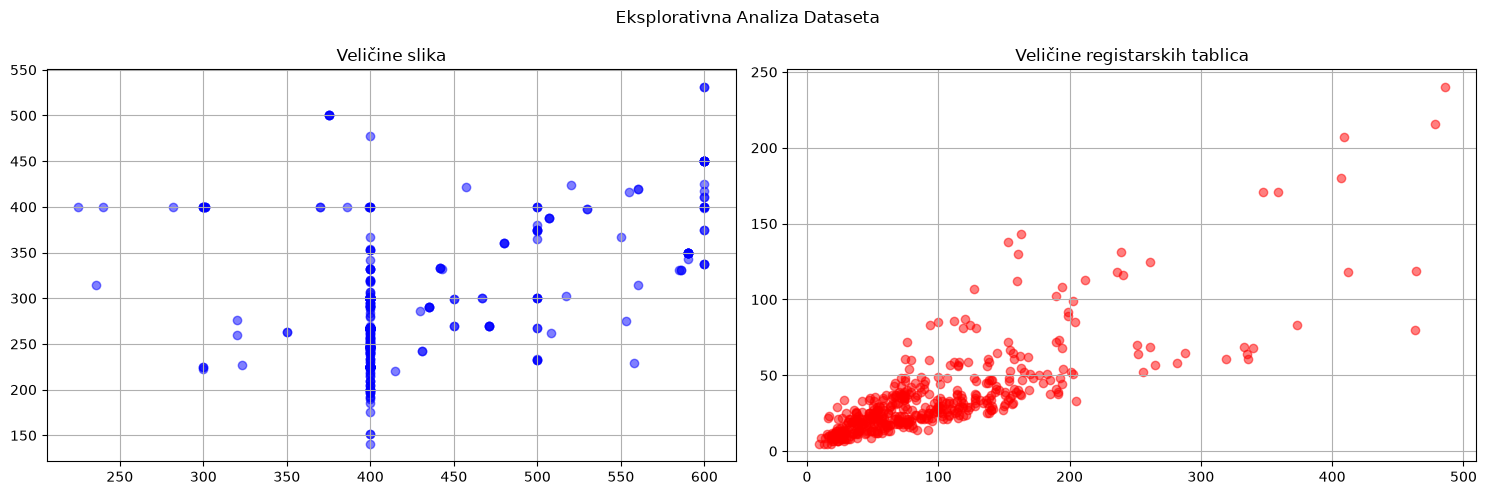

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(' Eksplorativna Analiza Dataseta')

axes[0].scatter(df['img_width'], df['img_height'], alpha=0.5, color='blue')
axes[0].set_title('Veličine slika')
axes[0].grid(True)

axes[1].scatter(df['box_w'], df['box_h'], alpha=0.5, color='red')
axes[1].set_title('Veličine registarskih tablica')
axes[1].grid(True)

plt.tight_layout()
plt.show()

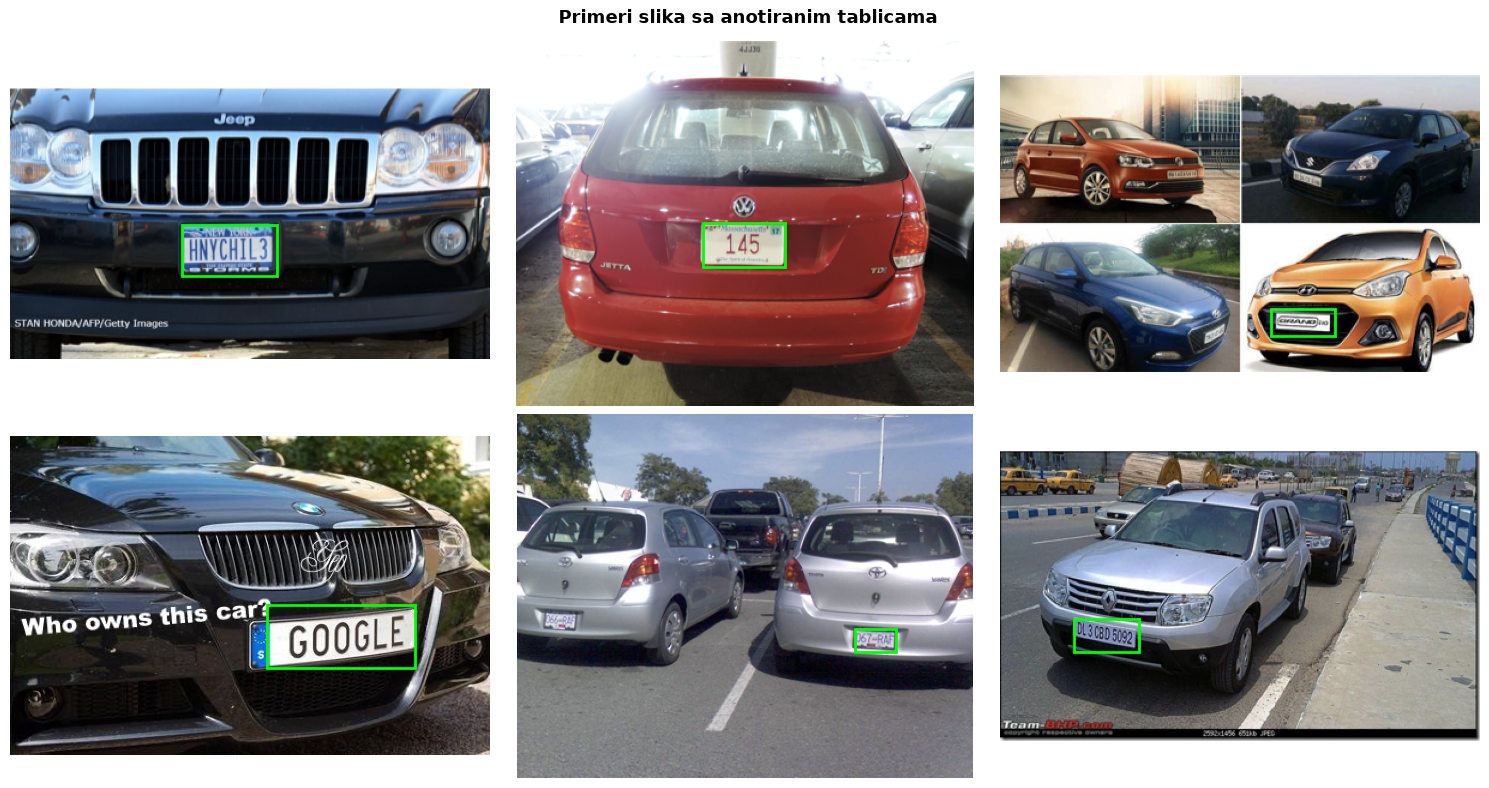

In [6]:
def show_sample_images(df, n=6):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(' Primeri slika sa anotiranim tablicama', fontsize=13, fontweight='bold')
    
    sample_rows = df.sample(n, random_state=SEED)
    
    for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
        img = np.array(Image.open(row['image_path']))
        ax.imshow(img)
        rect = patches.Rectangle(
            (row['xmin'], row['ymin']),
            row['box_w'], row['box_h'],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.axis('off')
        ax.add_patch(rect)
    
    plt.tight_layout()
    plt.show()

show_sample_images(df)

## 3.4 Preprocesiranje Podataka

Pripremamo podatke za sva 3 modela:
- **OpenCV pipeline:** slike se obrađuju direktno
- **CNN:** slike se skaliraju na 224×224 i normalizuju
- **YOLO:** slike i anotacije se konvertuju u YOLO format

Split dataseta:
   Train:      303 slika (70.0%)
   Validation: 65 slika  (15.0%)
   Test:       65 slika  (15.0%)


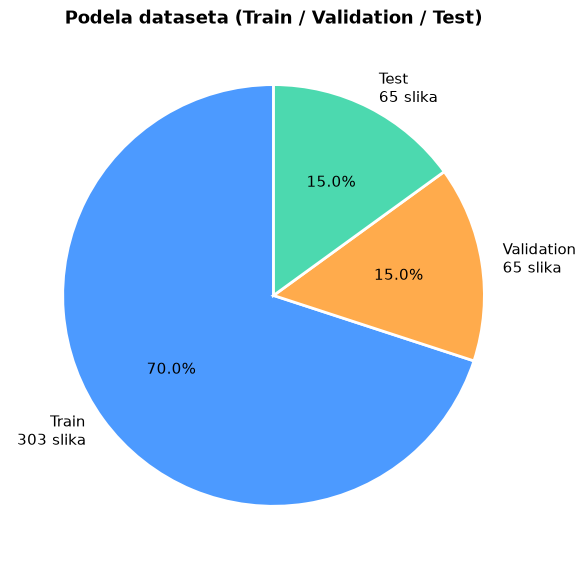

In [7]:
# ============================================================
#  SPLIT: Train / Validation / Test  (70 / 15 / 15)
# ============================================================
unique_images = df['image_path'].unique()

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.30, random_state=SEED)
val_imgs, test_imgs   = train_test_split(temp_imgs,     test_size=0.50, random_state=SEED)

print("Split dataseta:")
print(f"   Train:      {len(train_imgs)} slika ({len(train_imgs)/len(unique_images)*100:.1f}%)")
print(f"   Validation: {len(val_imgs)} slika  ({len(val_imgs)/len(unique_images)*100:.1f}%)")
print(f"   Test:       {len(test_imgs)} slika  ({len(test_imgs)/len(unique_images)*100:.1f}%)")

df_train = df[df['image_path'].isin(train_imgs)].reset_index(drop=True)
df_val   = df[df['image_path'].isin(val_imgs)].reset_index(drop=True)
df_test  = df[df['image_path'].isin(test_imgs)].reset_index(drop=True)

# ============================================================
#  Raspodela Train / Validation / Test skupa
# ============================================================
sizes = [len(train_imgs), len(val_imgs), len(test_imgs)]
labels = [f'Train\n{len(train_imgs)} slika', f'Validation\n{len(val_imgs)} slika', f'Test\n{len(test_imgs)} slika']
colors = ['#4C9AFF', '#FFAB4C', '#4CD9AF']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Podela dataseta (Train / Validation / Test)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
#  4. Model 1: OpenCV + EasyOCR Pipeline

In [8]:
import easyocr

reader = easyocr.Reader(['en'], gpu=torch.cuda.is_available())

def detect_plate_opencv(image_path):
    """
    Detekcija registarske tablice klasičnim OpenCV pristupom.
    Vraća (kandidat_box, slika_sa_crtežom)
    """
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Korak 1: Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Korak 2: Bilateral filter (čuva ivice, gladi šum)
    blurred = cv2.bilateralFilter(gray, 11, 17, 17)
    
    # Korak 3: Detekcija ivica (Canny)
    edges = cv2.Canny(blurred, 30, 200)
    
    # Korak 4: Pronalazak kontura
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:20]
    
    plate_box = None
    for cnt in contours:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.018 * peri, True)
        
        # Tražimo pravougaonu konturu (4 ugla)
        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / float(h)
            # Tablice obično imaju aspect ratio između 2 i 6
            if 2.0 <= aspect_ratio <= 6.0 and w > 60:
                plate_box = (x, y, x+w, y+h)
                break
    
    # Crtaj rezultat
    result_img = img_rgb.copy()
    if plate_box:
        cv2.rectangle(result_img,
                      (plate_box[0], plate_box[1]),
                      (plate_box[2], plate_box[3]),
                      (0, 255, 0), 3)
        cv2.putText(result_img, 'Tablica (OpenCV)',
                    (plate_box[0], plate_box[1]-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)
    
    return plate_box, result_img


def read_plate_text(image_path, box):
    """Koristi EasyOCR da pročita tekst sa regiona tablice."""
    if box is None:
        return ""
    img = cv2.imread(image_path)
    xmin, ymin, xmax, ymax = box
    # Malo proširi region za bolji OCR
    pad = 5
    crop = img[max(0,ymin-pad):ymax+pad, max(0,xmin-pad):xmax+pad]
    if crop.size == 0:
        return ""
    results = reader.readtext(crop)
    text = ' '.join([r[1] for r in results])
    return text.strip()

In [9]:
def compute_iou(box1, box2):
    """
    Izračunava IoU (Intersection over Union) između dva bounding boxa.
    Vrednost između 0 (bez preklapanja) i 1 (savršeno poklapanje).
    """
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter = max(0, x2-x1) * max(0, y2-y1)
    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])
    union = area1 + area2 - inter
    
    return inter / union if union > 0 else 0.0


# ============================================================
#  Evaluacija OpenCV modela na test setu
# ============================================================
print(" Evaluacija...")

opencv_results = []
IOU_THRESHOLD = 0.4  # Detekcija je uspešna ako je IoU > 0.4

test_unique = df_test['image_path'].unique()

for img_path in test_unique:
    # Uzmi sve ground-truth boxove za ovu sliku
    gt_boxes = df_test[df_test['image_path'] == img_path][['xmin','ymin','xmax','ymax']].values
    
    start_t = time.time()
    pred_box, _ = detect_plate_opencv(img_path)
    elapsed = time.time() - start_t
    
    # Izračunaj IoU sa svakim GT boxom
    best_iou = 0.0
    if pred_box is not None:
        for gt in gt_boxes:
            iou = compute_iou(pred_box, tuple(gt))
            best_iou = max(best_iou, iou)
    
    detected = best_iou >= IOU_THRESHOLD
    
    # OCR samo ako je detekcija uspela
    ocr_text = ""
    if detected:
        ocr_text = read_plate_text(img_path, pred_box)
    
    opencv_results.append({
        'image': os.path.basename(img_path),
        'detected': detected,
        'best_iou': best_iou,
        'inference_time': elapsed,
        'ocr_text': ocr_text
    })

df_opencv = pd.DataFrame(opencv_results)

opencv_accuracy  = df_opencv['detected'].mean()
opencv_mean_iou  = df_opencv['best_iou'].mean()
opencv_avg_time  = df_opencv['inference_time'].mean()

print(f"\n OpenCV Rezultati:")
print(f"   Tačnost detekcije: {opencv_accuracy:.3f} ({opencv_accuracy*100:.1f}%)")
print(f"   Prosečni IoU:      {opencv_mean_iou:.3f}")
print(f"   Vreme inf. (avg):  {opencv_avg_time*1000:.1f}ms")
print(f"   OCR uzorci: {df_opencv['ocr_text'].head(5).tolist()}")

 Evaluacija...

 OpenCV Rezultati:
   Tačnost detekcije: 0.246 (24.6%)
   Prosečni IoU:      0.203
   Vreme inf. (avg):  21.5ms
   OCR uzorci: ['', '', '', '', '']


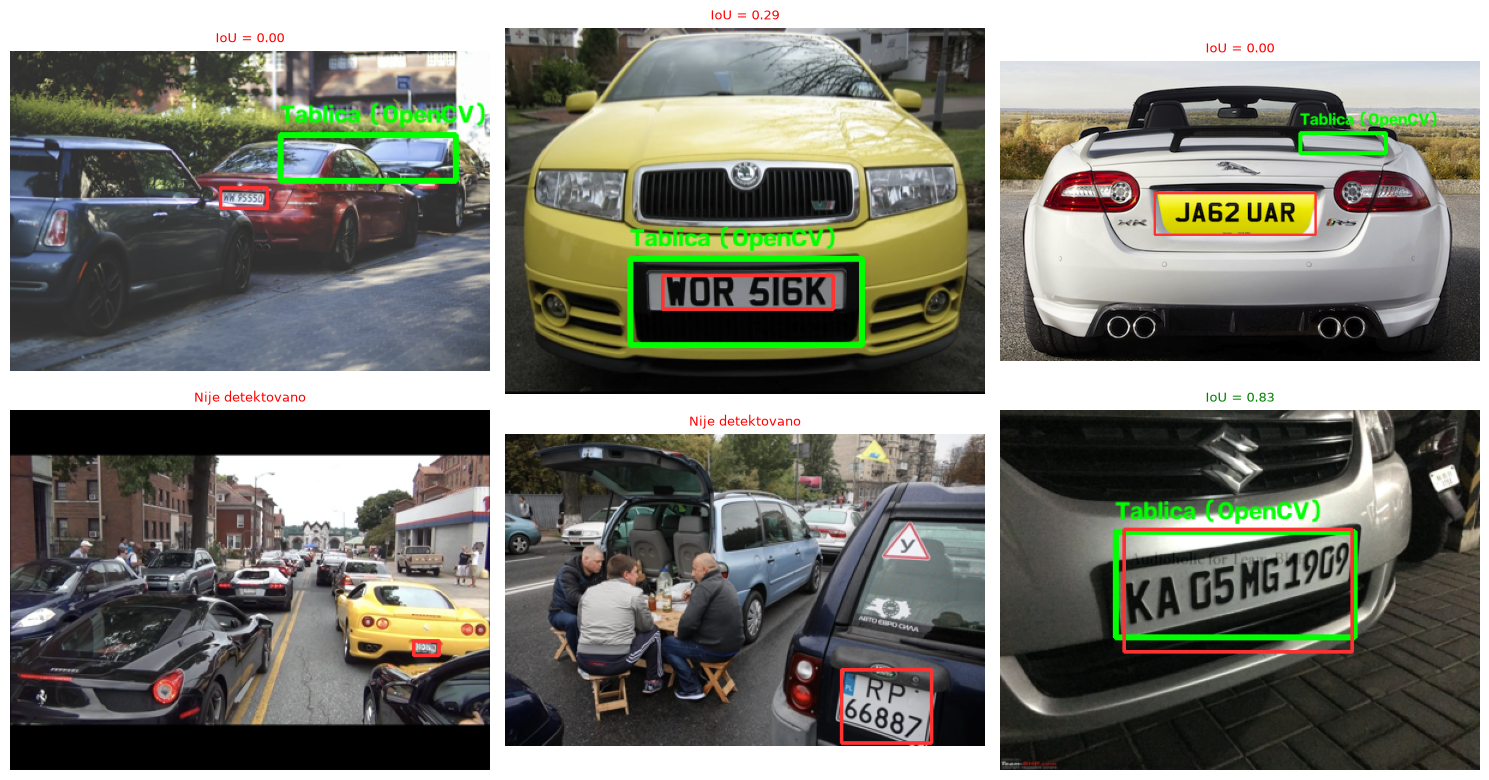

In [10]:
# Vizualizuj par primera iz OpenCV pipeline-a
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sample_paths = test_unique[:6]

for ax, img_path in zip(axes.flatten(), sample_paths):
    pred_box, result_img = detect_plate_opencv(img_path)
    
    gt_row = df_test[df_test['image_path'] == img_path].iloc[0]
    cv2.rectangle(result_img,
                  (gt_row['xmin'], gt_row['ymin']),
                  (gt_row['xmax'], gt_row['ymax']),
                  (255, 50, 50), 2)
    
    ax.imshow(result_img)
    
    # Prikazi IoU u naslovu
    if pred_box:
        iou = compute_iou(pred_box, (gt_row['xmin'], gt_row['ymin'], gt_row['xmax'], gt_row['ymax']))
        ax.set_title(f'IoU = {iou:.2f}', color='green' if iou >= IOU_THRESHOLD else 'red', fontsize=9)
    else:
        ax.set_title('Nije detektovano', color='red', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
#  5. Model 2: Custom CNN

## Arhitektura



Arhitektura: **3 Conv bloka → Global Average Pooling → FC slojevi**

```
Input (3×224×224)
  ↓
Conv1 (3→32, 3×3) → BN → ReLU → MaxPool
  ↓
Conv2 (32→64, 3×3) → BN → ReLU → MaxPool  
  ↓
Conv3 (64→128, 3×3) → BN → ReLU → MaxPool
  ↓
Global Avg Pool → FC(512) → Dropout → FC(2)
```

In [11]:
# ============================================================
#  Custom CNN Arhitektura
# ============================================================
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 224→112
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 112→56
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),            # 56→28
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4))   # Global pooling → 4×4
        )
        
        # --- Klasifikator ---
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x


model_cnn = CustomCNN(num_classes=2).to(DEVICE)
dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
out = model_cnn(dummy)
print(f" Output shape: {out.shape}")

total_params = sum(p.numel() for p in model_cnn.parameters())
trainable_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"   Ukupno parametara:    {total_params:,}")
print(f"   Trenirajuci parametri: {trainable_params:,}")

 Output shape: torch.Size([2, 2])
   Ukupno parametara:    2,488,066
   Trenirajuci parametri: 2,488,066


In [12]:
# ============================================================
#  Dataset klasa za CNN
# ============================================================
class PlateDataset(Dataset):
    """
    PyTorch Dataset za registarske tablice.
    Pozitivni primeri: isecak slike sa tablicom (label=1)
    Negativni primeri: nasumični isecak bez tablice (label=0)
    """
    def __init__(self, df, transform=None, negative_ratio=1.0):
        self.transform = transform
        self.samples = []
        
        for _, row in df.iterrows():
            img_path = row['image_path']
            
            # Pozitivan primer: region tablice
            self.samples.append({
                'path': img_path,
                'box': (row['xmin'], row['ymin'], row['xmax'], row['ymax']),
                'label': 1
            })
            
            # Negativan primer: nasumicni region
            if random.random() < negative_ratio:
                img = Image.open(img_path)
                w, h = img.size
                # Isecak koji ne prelapa sa tablicom
                nx = random.randint(0, max(0, w//2 - 50))
                ny = random.randint(0, max(0, h//4 - 30))
                nw = random.randint(60, w//3)
                nh = random.randint(30, h//3)
                self.samples.append({
                    'path': img_path,
                    'box': (nx, ny, min(nx+nw, w), min(ny+nh, h)),
                    'label': 0
                })
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['path']).convert('RGB')
        x1, y1, x2, y2 = sample['box']
        img = img.crop((x1, y1, x2, y2))
        
        if self.transform:
            img = self.transform(img)
        
        return img, sample['label']


# Transformacije sa augmentacijom za trening
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


train_dataset = PlateDataset(df_train, transform=train_transforms, negative_ratio=1.0)
val_dataset   = PlateDataset(df_val,   transform=val_transforms,   negative_ratio=1.0)
test_dataset  = PlateDataset(df_test,  transform=val_transforms,   negative_ratio=1.0)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f" DataLoaderi kreirani:")
print(f"   Train:  {len(train_dataset)} uzoraka")
print(f"   Val:    {len(val_dataset)} uzoraka")
print(f"   Test:   {len(test_dataset)} uzoraka")

 DataLoaderi kreirani:
   Train:  670 uzoraka
   Val:    138 uzoraka
   Test:   134 uzoraka


In [13]:
# ============================================================
#  Trening CNN modela
# ============================================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss/total, correct/total, all_preds, all_labels


# Parametri treninga
NUM_EPOCHS = 20
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model_cnn.parameters(), lr=0.001, weight_decay=0.0001)
scheduler  = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

cnn_train_start = time.time()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print(f" Pokretanje treninga CNN modela ({NUM_EPOCHS} epoha)...")
print(f"{'Ep':>4} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print('-' * 55)

for epoch in range(NUM_EPOCHS):
    t_loss, t_acc = train_epoch(model_cnn, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc, _, _ = eval_epoch(model_cnn, val_loader, criterion, DEVICE)
    scheduler.step()
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model_cnn.state_dict(), 'best_cnn.pth')
    
    
    print(f"{epoch+1:>4} | {t_loss:>10.4f} | {t_acc:>9.4f} | {v_loss:>8.4f} | {v_acc:>8.4f}")

print(f"\n Trening završen! Najboja val accuracy: {best_val_acc:.4f}")
cnn_train_time = time.time() - cnn_train_start
print(f"\nUkupno vreme treninga CNN: {cnn_train_time:.1f}s ({cnn_train_time/60:.2f} min)")

 Pokretanje treninga CNN modela (20 epoha)...
  Ep | Train Loss | Train Acc | Val Loss |  Val Acc
-------------------------------------------------------
   1 |     0.7178 |    0.6776 |   0.3968 |   0.8333
   2 |     0.3289 |    0.8582 |   0.2728 |   0.8696
   3 |     0.2639 |    0.8970 |   0.2670 |   0.8913
   4 |     0.2266 |    0.9164 |   0.2935 |   0.8841
   5 |     0.2068 |    0.9254 |   0.2106 |   0.9130
   6 |     0.1964 |    0.9239 |   0.2367 |   0.8768
   7 |     0.2160 |    0.9224 |   0.2677 |   0.8768
   8 |     0.1552 |    0.9328 |   0.3057 |   0.8986
   9 |     0.1347 |    0.9522 |   0.2090 |   0.9420
  10 |     0.1138 |    0.9552 |   0.1959 |   0.9203
  11 |     0.1091 |    0.9612 |   0.1586 |   0.9348
  12 |     0.0937 |    0.9627 |   0.1869 |   0.9348
  13 |     0.0729 |    0.9746 |   0.1563 |   0.9275
  14 |     0.0825 |    0.9672 |   0.1085 |   0.9420
  15 |     0.0658 |    0.9791 |   0.1370 |   0.9348
  16 |     0.0661 |    0.9806 |   0.1072 |   0.9493
  17 |     0.0

In [14]:
# ============================================================
#  Custom CNN — merenje pravog vremena inferencije
# ============================================================
model_cnn.eval()

# Warm-up (prvi GPU poziv je sporiji zbog inicijalizacije kernela — ne računamo ga)
with torch.no_grad():
    dummy_input = test_dataset[0][0].unsqueeze(0).to(DEVICE)
    for _ in range(5):
        _ = model_cnn(dummy_input)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

cnn_inference_times = []

with torch.no_grad():
    for img_tensor, label in test_dataset:
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        start_t = time.time()

        _ = model_cnn(img_tensor)

        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start_t

        cnn_inference_times.append(elapsed)

cnn_avg_time = np.mean(cnn_inference_times)
print(f"Custom CNN vreme inferencije (avg, batch=1): {cnn_avg_time*1000:.2f}ms")

Custom CNN vreme inferencije (avg, batch=1): 2.76ms


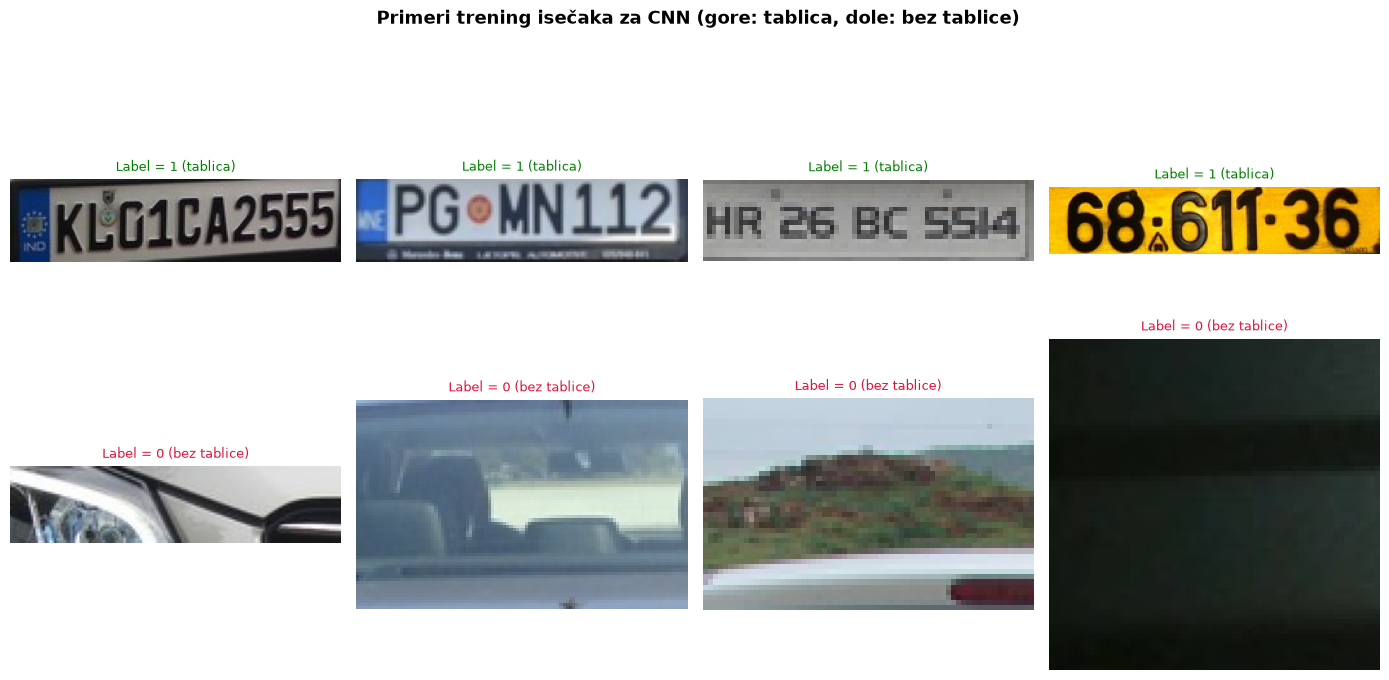

In [15]:
# ============================================================
#  Primeri pozitivnih (tablica) i negativnih (bez tablice) isečaka
# ============================================================
positives = [s for s in train_dataset.samples if s['label'] == 1][:4]
negatives = [s for s in train_dataset.samples if s['label'] == 0][:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(' Primeri trening isečaka za CNN (gore: tablica, dole: bez tablice)',
             fontsize=13, fontweight='bold')

for ax, sample in zip(axes[0], positives):
    img = Image.open(sample['path']).convert('RGB').crop(sample['box'])
    ax.imshow(img)
    ax.set_title('Label = 1 (tablica)', color='green', fontsize=9)
    ax.axis('off')

for ax, sample in zip(axes[1], negatives):
    img = Image.open(sample['path']).convert('RGB').crop(sample['box'])
    ax.imshow(img)
    ax.set_title('Label = 0 (bez tablice)', color='crimson', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

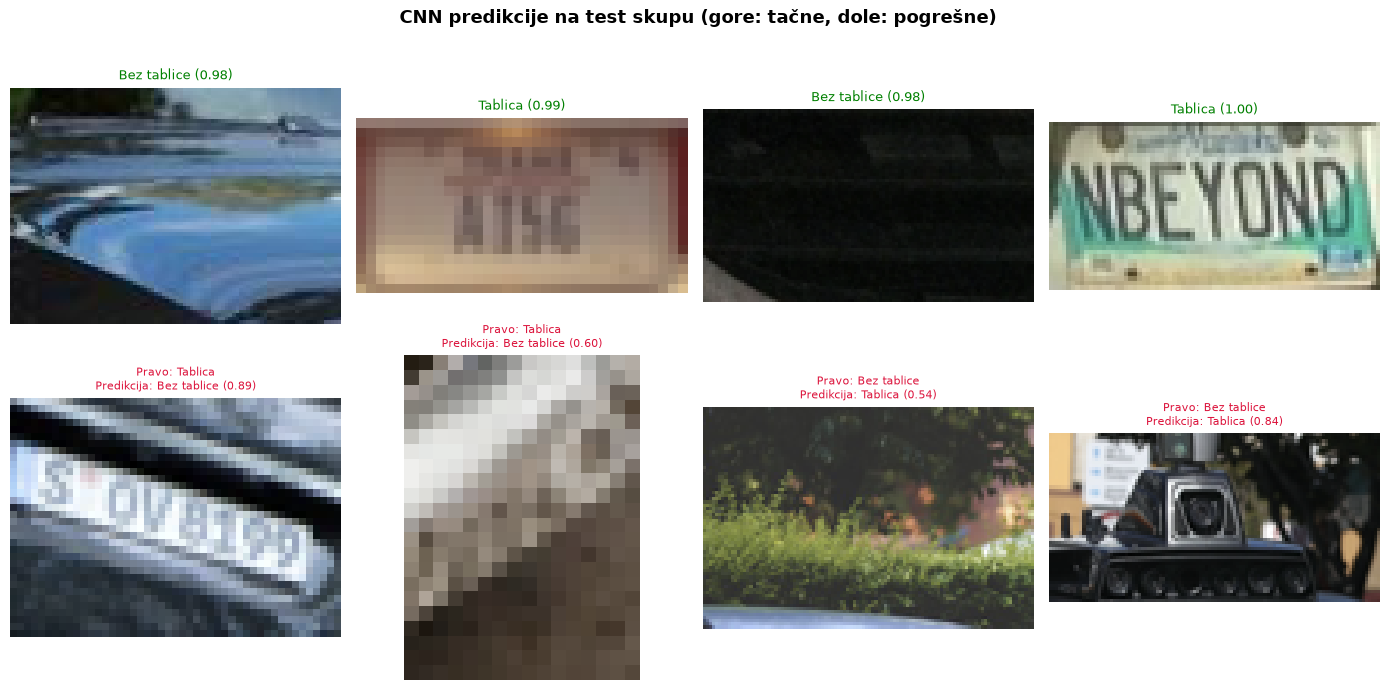

In [16]:
# ============================================================
#  Primeri CNN predikcija na test skupu (sa verovatnoćom)
# ============================================================
model_cnn.eval()

results = []
with torch.no_grad():
    for i in range(len(test_dataset)):
        img_tensor, label = test_dataset[i]
        logits = model_cnn(img_tensor.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(logits, dim=1)[0]
        pred = prob.argmax().item()
        results.append({
            'idx': i,
            'label': label,
            'pred': pred,
            'confidence': prob[pred].item(),
            'correct': pred == label
        })

df_results = pd.DataFrame(results)

# 4 tacne + 4 pogresne (ako ih ima)
correct_samples = df_results[df_results['correct']].sample(min(4, df_results['correct'].sum()), random_state=SEED)
wrong_samples = df_results[~df_results['correct']]
wrong_samples = wrong_samples.sample(min(4, len(wrong_samples)), random_state=SEED) if len(wrong_samples) > 0 else wrong_samples

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(' CNN predikcije na test skupu (gore: tačne, dole: pogrešne)',
             fontsize=13, fontweight='bold')

label_map = {0: 'Bez tablice', 1: 'Tablica'}

for ax, (_, row) in zip(axes[0], correct_samples.iterrows()):
    img_tensor, _ = test_dataset[row['idx']]
    sample = test_dataset.samples[row['idx']]
    img = Image.open(sample['path']).convert('RGB').crop(sample['box'])
    ax.imshow(img)
    ax.set_title(f"{label_map[row['pred']]} ({row['confidence']:.2f})", color='green', fontsize=9)
    ax.axis('off')

for ax in axes[0][len(correct_samples):]:
    ax.axis('off')

if len(wrong_samples) > 0:
    for ax, (_, row) in zip(axes[1], wrong_samples.iterrows()):
        img_tensor, _ = test_dataset[row['idx']]
        sample = test_dataset.samples[row['idx']]
        img = Image.open(sample['path']).convert('RGB').crop(sample['box'])
        ax.imshow(img)
        ax.set_title(f"Pravo: {label_map[row['label']]}\nPredikcija: {label_map[row['pred']]} ({row['confidence']:.2f})",
                     color='crimson', fontsize=8)
        ax.axis('off')
    for ax in axes[1][len(wrong_samples):]:
        ax.axis('off')
else:
    for ax in axes[1]:
        ax.axis('off')
    axes[1][0].text(0.5, 0.5, 'Nema pogrešnih\npredikcija u uzorku',
                     ha='center', va='center', fontsize=11)

plt.tight_layout()
plt.show()

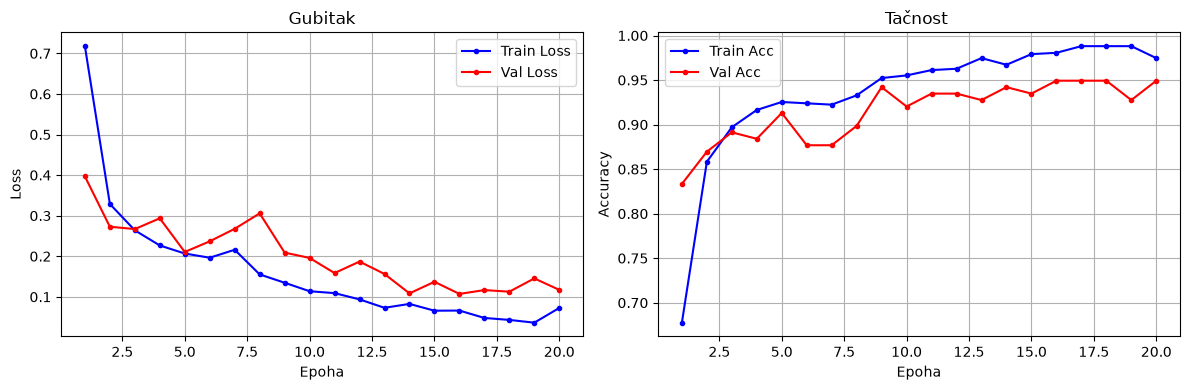


 CNN Test Rezultati:
   Test Accuracy: 0.9701 (97.01%)
   F1 Score:      0.9697
   Precision:     0.9846
   Recall:        0.9552


In [17]:
# Krivulje učenja
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS+1)

axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train Loss')
axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val Loss')
axes[0].set_xlabel('Epoha'); axes[0].set_ylabel('Loss')
axes[0].set_title('Gubitak'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=3, label='Train Acc')
axes[1].plot(epochs, history['val_acc'],   'r-o', markersize=3, label='Val Acc')
axes[1].set_xlabel('Epoha'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Tačnost '); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluacija na test setu
model_cnn.load_state_dict(torch.load('best_cnn.pth', map_location=DEVICE))
_, cnn_test_acc, cnn_preds, cnn_labels = eval_epoch(model_cnn, test_loader, criterion, DEVICE)

print(f"\n CNN Test Rezultati:")
print(f"   Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")
print(f"   F1 Score:      {f1_score(cnn_labels, cnn_preds):.4f}")
print(f"   Precision:     {precision_score(cnn_labels, cnn_preds):.4f}")
print(f"   Recall:        {recall_score(cnn_labels, cnn_preds):.4f}")

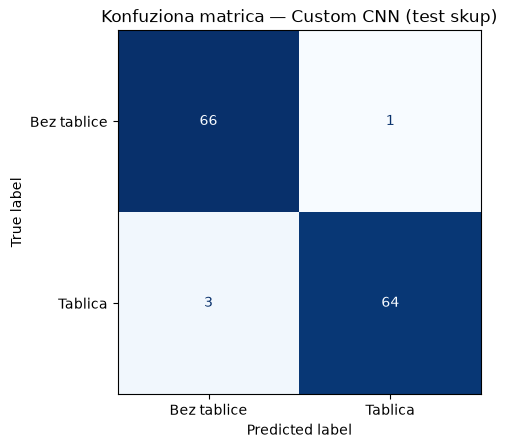

In [18]:
# ============================================================
#  Konfuziona matrica — Custom CNN
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(cnn_labels, cnn_preds)

fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Bez tablice', 'Tablica'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Konfuziona matrica — Custom CNN (test skup)')
plt.tight_layout()
plt.show()

---
# 🎯 6. Model 3: YOLOv8 (You Only Look Once)

## Šta je YOLO?

YOLOv8 je najmoderniji (state-of-the-art) model za detekciju objekata. Za razliku od OpenCV koji koristi ručno pisana pravila, YOLO uči direktno iz podataka.

## Priprema podataka za YOLO format
YOLO koristi specifičan format: `class x_center y_center width height` (sve normalizovano na [0,1])

In [19]:
import shutil

# ============================================================
#  Konverzija anotacija u YOLO format
# ============================================================
YOLO_DIR = Path('yolo_dataset')

for split, paths in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
    (YOLO_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

def convert_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    """
    Konvertuje Pascal VOC box u YOLO format.
    YOLO: x_center, y_center, width, height (sve između 0 i 1)
    """
    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    width    = (xmax - xmin) / img_w
    height   = (ymax - ymin) / img_h
    return x_center, y_center, width, height

# Kopiraj slike i napravi label fajlove
for split_name, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    grouped = split_df.groupby('image_path')
    for img_path, group in grouped:
        # Kopiraj sliku
        dst_img = YOLO_DIR / split_name / 'images' / os.path.basename(img_path)
        shutil.copy(img_path, dst_img)
        
        # Napiši label fajl
        label_name = Path(os.path.basename(img_path)).stem + '.txt'
        dst_lbl = YOLO_DIR / split_name / 'labels' / label_name
        
        with open(dst_lbl, 'w') as f:
            for _, row in group.iterrows():
                xc, yc, w, h = convert_to_yolo(
                    row['xmin'], row['ymin'], row['xmax'], row['ymax'],
                    row['img_width'], row['img_height']
                )
                f.write(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

# Napiši YOLO config fajl
yaml_content = f"""path: {YOLO_DIR.absolute()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['license_plate']
"""
with open('plate_dataset.yaml', 'w') as f:
    f.write(yaml_content)

print(" YOLO dataset struktura kreirana!")
print(f"   Sadržaj: {list(YOLO_DIR.iterdir())}")

 YOLO dataset struktura kreirana!
   Sadržaj: [WindowsPath('yolo_dataset/test'), WindowsPath('yolo_dataset/train'), WindowsPath('yolo_dataset/val')]


In [20]:
from ultralytics import YOLO

# ============================================================
#  YOLOv8 - Fine-tuning na našem datasetu
# ============================================================
# Koristimo YOLOv8n (nano) - najmanji i najbrži
# 'n' = nano, 's' = small, 'm' = medium, 'l' = large
print(" Pokretanje YOLOv8 treninga...")
print("   Koristimo YOLOv8n (pretrained na COCO datasetu)")
print("   Fine-tuning na license plate datasetu...\n")

yolo_model = YOLO('yolov8n.pt')  # Preuzima pretrained model

# Trening
results_yolo = yolo_model.train(
    data='plate_dataset.yaml',
    epochs=30,
    imgsz=640,
    batch=8, #sa 16 na 8, ostajemo bez memorije
    name='plate_detector',
    patience=10,          # Early stopping
    save=True,
    plots=True,
    verbose=False
)

print("\n YOLOv8 trening završen!")

 Pokretanje YOLOv8 treninga...
   Koristimo YOLOv8n (pretrained na COCO datasetu)
   Fine-tuning na license plate datasetu...

New https://pypi.org/project/ultralytics/8.4.147 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.138  Python-3.11.9 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plate_dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.

In [21]:
# ============================================================
#  YOLOv8 Evaluacija
# ============================================================
# Učitaj trenutni model
best_yolo = YOLO(results_yolo.save_dir / 'weights' / 'best.pt')
#best_yolo = YOLO('runs/detect/plate_detector-11/weights/best.pt') #iz datoteke

yolo_results_csv = results_yolo.save_dir / 'results.csv'
df_yolo_time = pd.read_csv(yolo_results_csv)
df_yolo_time.columns = df_yolo_time.columns.str.strip()
# Validacija na test setu
yolo_val = best_yolo.val(
    data='plate_dataset.yaml',
    split='test',
    verbose=True
)

# Izvuci metrike
yolo_map50   = yolo_val.box.map50    # mAP@0.5
yolo_map5095 = yolo_val.box.map      # mAP@0.5:0.95
yolo_precision = yolo_val.box.mp
yolo_recall    = yolo_val.box.mr
yolo_train_time = df_yolo_time['time'].iloc[-1]  # kumulativno vreme, poslednja epoha

print(f"Ukupno vreme treninga YOLOv8n: {yolo_train_time:.1f}s ({yolo_train_time/60:.2f} min)")
print(f"\n YOLOv8 Test Rezultati:")
print(f"   mAP@0.50:      {yolo_map50:.4f}")
print(f"   mAP@0.50:0.95: {yolo_map5095:.4f}")
print(f"   Precision:     {yolo_precision:.4f}")
print(f"   Recall:        {yolo_recall:.4f}")

Ultralytics 8.4.138  Python-3.11.9 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING val: Slow image access detected (ping: 0.10.0 ms, read: 22.96.9 MB/s, size: 522.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning D:\UNI\2025-2026\Semestar II\MasinskoUcenje\OiPRT\ANPR\yolo_dataset\test\labels.cache... 65 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 65/65  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.2it/s 4.2s0.4s1s
                   all         65         67       0.88      0.878      0.905      0.466
Speed: 2.2ms preprocess, 6.0ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to D:\UNI\2025-2026\Semestar II\MasinskoUcenje\OiPRT\ANPR\runs\detect\val
Ukupno vreme treninga YOLOv

In [22]:
# ============================================================
#  YOLOv8 — Detection Accuracy (ista definicija kao za OpenCV)
# ============================================================
yolo_results = []

for img_path in test_unique:
    gt_boxes = df_test[df_test['image_path'] == img_path][['xmin','ymin','xmax','ymax']].values

    start_t = time.time()
    results = best_yolo.predict(img_path, conf=0.25, verbose=False)
    elapsed = time.time() - start_t

    best_iou = 0.0
    boxes = results[0].boxes
    if len(boxes) > 0:
        # uzmi box sa najvišim confidence-om
        best_idx = boxes.conf.argmax()
        pred_box = tuple(map(int, boxes.xyxy[best_idx].cpu().numpy()))
        for gt in gt_boxes:
            iou = compute_iou(pred_box, tuple(gt))
            best_iou = max(best_iou, iou)

    detected = best_iou >= IOU_THRESHOLD  # isti prag = 0.4 kao kod OpenCV

    yolo_results.append({
        'image': os.path.basename(img_path),
        'detected': detected,
        'best_iou': best_iou,
        'inference_time': elapsed
    })

df_yolo_det = pd.DataFrame(yolo_results)
yolo_detection_accuracy = df_yolo_det['detected'].mean()
yolo_mean_iou_matched   = df_yolo_det['best_iou'].mean()
yolo_avg_time           = df_yolo_det['inference_time'].mean()

print(f"YOLOv8 Detection Accuracy (IoU≥{IOU_THRESHOLD}): {yolo_detection_accuracy:.3f}")
print(f"YOLOv8 prosečni IoU:                          {yolo_mean_iou_matched:.3f}")
print(f"YOLOv8 vreme inferencije (avg):                {yolo_avg_time*1000:.1f}ms")

YOLOv8 Detection Accuracy (IoU≥0.4): 0.892
YOLOv8 prosečni IoU:                          0.682
YOLOv8 vreme inferencije (avg):                37.4ms


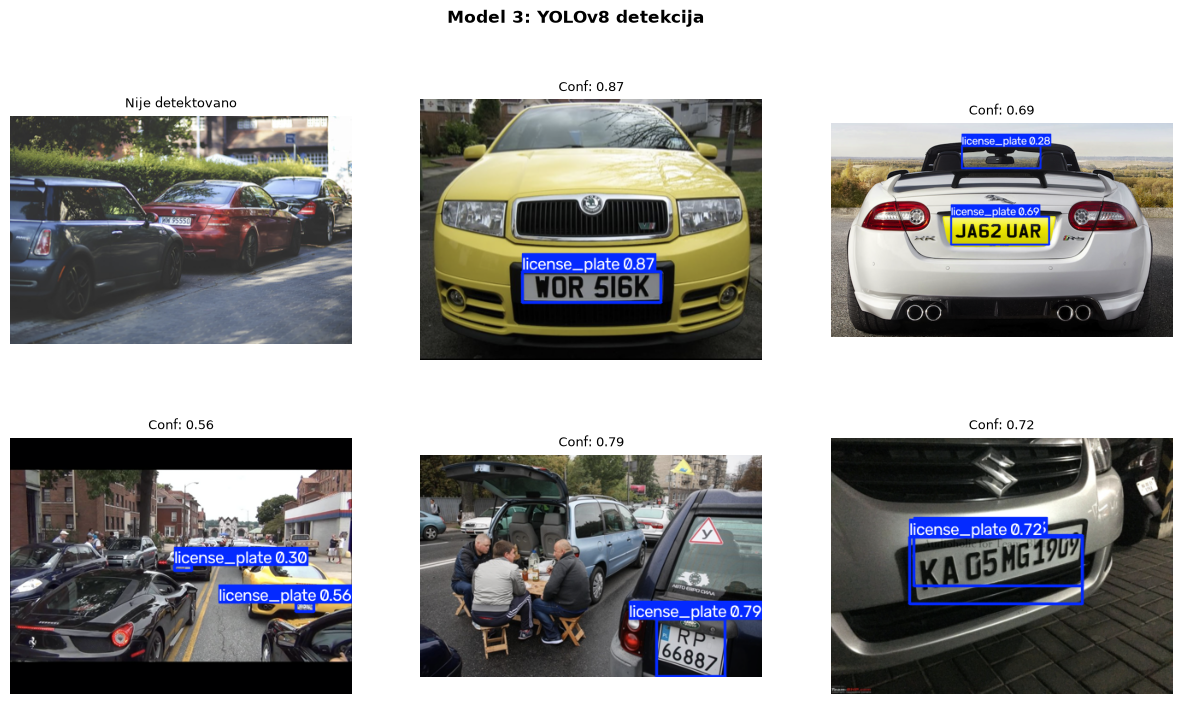

In [23]:
# Vizualizuj YOLO predikcije
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(' Model 3: YOLOv8 detekcija', fontsize=12, fontweight='bold')

for ax, img_path in zip(axes.flatten(), test_unique[:6]):
    results = best_yolo.predict(img_path, conf=0.25, verbose=False)
    result_img = results[0].plot()  
    result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
    
    # Confidence score
    conf_scores = results[0].boxes.conf.cpu().numpy() if len(results[0].boxes) > 0 else []
    title = f"Conf: {conf_scores[0]:.2f}" if len(conf_scores) > 0 else "Nije detektovano"
    
    ax.imshow(result_img)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.show()

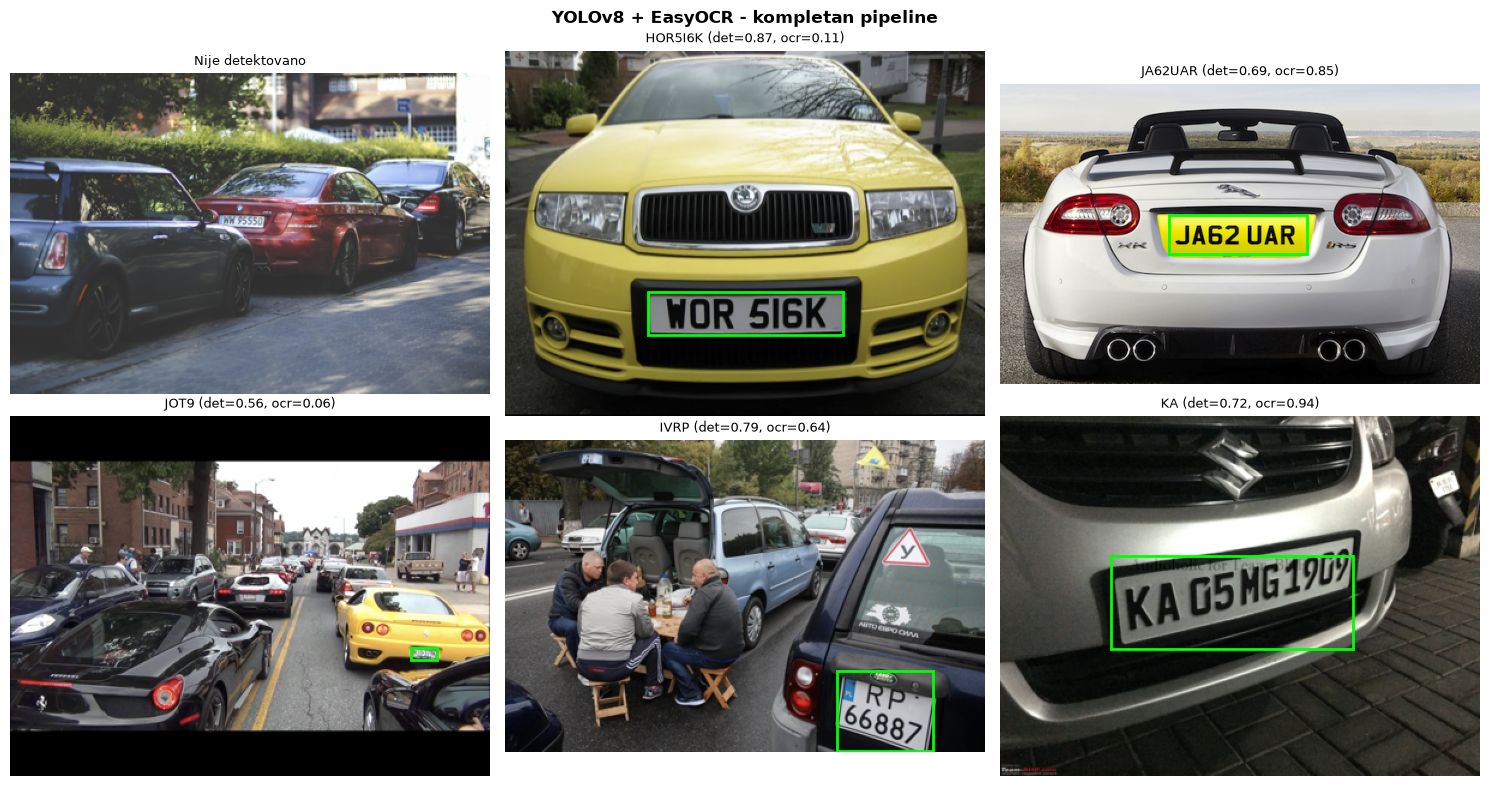


 YOLOv8 + EasyOCR Pipeline — Rezultati na test skupu:
   Stopa detekcije:        0.923 (92.3%)
   Stopa nepraznog OCR-a:  0.892 (89.2%)
   Prosečno vreme (avg):   51.3ms

   Primeri prepoznatog teksta: ['HOR5I6K', 'JA62UAR', 'JOT9', 'IVRP', 'KA', 'IZZ', '0NZI015', '7HIG26', '0165', 'DL3CHDE']


In [24]:
# ============================================================
#  YOLOv8 + EasyOCR — kompletan pipeline (detekcija + čitanje teksta)
# ============================================================
def preprocess_plate_region(crop):
    """
    Predobrada izdvojenog regiona registarske tablice pre OCR-a.
    Koraci: konverzija u nijanse sive, uvećanje (upscale) radi bolje čitljivosti,
    i adaptivna binarizacija za poboljšanje kontrasta karaktera.
    """
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    # Uvećanje regiona (mali regioni tablica -> bolji OCR na većoj rezoluciji)
    scale = 2
    gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # Adaptivna binarizacija (robustnija od globalnog thresholda na promenljivo osvetljenje)
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 15
    )
    return thresh


def clean_plate_text(raw_text):
    """
    Post-obrada teksta dobijenog iz OCR-a: uklanja razmake i karaktere
    koji nisu slova/brojevi (registarske tablice sadrže samo alfanumeričke znakove).
    """
    text = raw_text.upper()
    text = re.sub(r'[^A-Z0-9]', '', text)
    return text


def detect_and_read_plate(image_path, yolo_model, ocr_reader, conf=0.25):
    """
    Vraća listu rečnika, po jedan za svaku detektovanu tablicu na slici:
    {'box': (x1,y1,x2,y2), 'confidence': float, 'text': str, 'ocr_confidence': float}
    """
    img = cv2.imread(image_path)
    if img is None:
        return []

    results = yolo_model.predict(image_path, conf=conf, verbose=False)
    detections = []

    boxes = results[0].boxes
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf = float(box.conf[0].cpu().numpy())

        pad = 4
        h, w = img.shape[:2]
        crop = img[max(0, y1 - pad):min(h, y2 + pad),
                    max(0, x1 - pad):min(w, x2 + pad)]

        if crop.size == 0:
            continue

        processed = preprocess_plate_region(crop)
        ocr_results = ocr_reader.readtext(processed)

        if ocr_results:
            best = max(ocr_results, key=lambda r: r[2])
            raw_text = best[1]
            ocr_conf = float(best[2])
            text = clean_plate_text(raw_text)
        else:
            text = ""
            ocr_conf = 0.0

        detections.append({
            'box': (x1, y1, x2, y2),
            'confidence': det_conf,
            'text': text,
            'ocr_confidence': ocr_conf
        })

    return detections


# ============================================================
#  Test pipeline-a na nekoliko slika iz test skupa
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('YOLOv8 + EasyOCR - kompletan pipeline', fontsize=12, fontweight='bold')

for ax, img_path in zip(axes.flatten(), test_unique[:6]):
    detections = detect_and_read_plate(img_path, best_yolo, reader)

    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    if detections:
        d = detections[0]
        x1, y1, x2, y2 = d['box']
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        title = f"{d['text']} (det={d['confidence']:.2f}, ocr={d['ocr_confidence']:.2f})"
    else:
        title = "Nije detektovano"

    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
#  Evaluacija OCR tačnosti pipeline-a na celom test skupu
# ============================================================
pipeline_results = []

for img_path in test_unique:
    start_t = time.time()
    detections = detect_and_read_plate(img_path, best_yolo, reader)
    elapsed = time.time() - start_t

    if detections:
        best_det = max(detections, key=lambda d: d['confidence'])
        pipeline_results.append({
            'image': os.path.basename(img_path),
            'detected': True,
            'text': best_det['text'],
            'det_confidence': best_det['confidence'],
            'ocr_confidence': best_det['ocr_confidence'],
            'inference_time': elapsed
        })
    else:
        pipeline_results.append({
            'image': os.path.basename(img_path),
            'detected': False,
            'text': '',
            'det_confidence': 0.0,
            'ocr_confidence': 0.0,
            'inference_time': elapsed
        })

df_pipeline = pd.DataFrame(pipeline_results)

pipeline_detection_rate = df_pipeline['detected'].mean()
pipeline_avg_time = df_pipeline['inference_time'].mean()
pipeline_nonempty_text = (df_pipeline['text'] != '').mean()

print(f"\n YOLOv8 + EasyOCR Pipeline — Rezultati na test skupu:")
print(f"   Stopa detekcije:        {pipeline_detection_rate:.3f} ({pipeline_detection_rate*100:.1f}%)")
print(f"   Stopa nepraznog OCR-a:  {pipeline_nonempty_text:.3f} ({pipeline_nonempty_text*100:.1f}%)")
print(f"   Prosečno vreme (avg):   {pipeline_avg_time*1000:.1f}ms")
print(f"\n   Primeri prepoznatog teksta: {df_pipeline[df_pipeline['text'] != '']['text'].head(10).tolist()}")

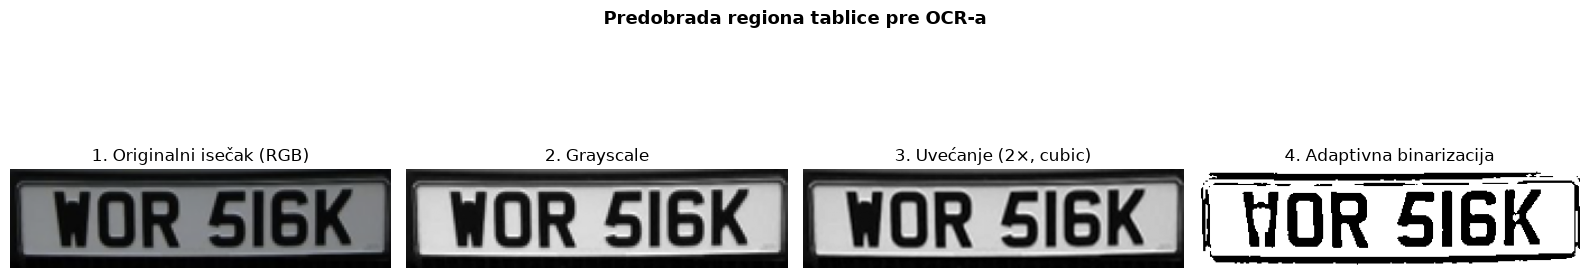

In [25]:
# ============================================================
#  Before/After — predobrada regiona tablice pre OCR-a
# ============================================================
sample_path = test_unique[1]   # promenite indeks ako želite drugi primer
detections = detect_and_read_plate(sample_path, best_yolo, reader)

if detections:
    d = detections[0]
    x1, y1, x2, y2 = d['box']
    img = cv2.imread(sample_path)
    pad = 4
    h, w = img.shape[:2]
    crop = img[max(0, y1-pad):min(h, y2+pad), max(0, x1-pad):min(w, x2+pad)]
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    scale = 2
    upscaled = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    thresh = cv2.adaptiveThreshold(upscaled, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 31, 15)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('Predobrada regiona tablice pre OCR-a', fontsize=13, fontweight='bold')

    axes[0].imshow(crop_rgb); axes[0].set_title('1. Originalni isečak (RGB)')
    axes[1].imshow(gray, cmap='gray'); axes[1].set_title('2. Grayscale')
    axes[2].imshow(upscaled, cmap='gray'); axes[2].set_title('3. Uvećanje (2×, cubic)')
    axes[3].imshow(thresh, cmap='gray'); axes[3].set_title('4. Adaptivna binarizacija')

    for ax in axes:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Nije detektovana tablica na ovoj slici, probajte drugi indeks u test_unique.")

---
#  7. Evaluacija i Poređenje Sva 3 Modela

## Metrike koje koristimo

| Metrika | Opis |
|---------|------|
| **IoU** | Intersection over Union — meri preklapanje predikcije i GT |
| **Precision** | Od svih detektovanih tablica, koliko je tačno? |
| **Recall** | Od svih pravih tablica, koliko je nađeno? |
| **F1 Score** | Harmonična sredina precision i recall |
| **mAP@0.5** | Mean Average Precision pri IoU=0.5 |
| **Inf. Time** | Vreme inferencije (ms/slika) |

In [34]:
# ============================================================
#  Centralizovano poređenje svih modela
# ============================================================
comparison_data = {
    'Model': ['OpenCV + EasyOCR', 'Custom CNN', 'YOLOv8n'],
    'Tip': ['Classical CV', 'Deep Learning', 'Deep Learning'],
    'Detection Acc. (IoU≥0.4)': [
        round(opencv_accuracy, 4),
        '-',                              # CNN ne radi lokalizaciju
        round(yolo_detection_accuracy, 4)  # ista definicija kao OpenCV
    ],
    'Prosečni IoU': [
        round(opencv_mean_iou, 4),
        '-',
        round(yolo_mean_iou_matched, 4)    # ista definicija kao OpenCV
    ],
    'Klasifikaciona Acc.': [
        '-',
        round(cnn_test_acc, 4),
        '-'
    ],
    'F1 Score': [
        '-',
        round(f1_score(cnn_labels, cnn_preds), 4),
        round(2 * yolo_precision * yolo_recall / (yolo_precision + yolo_recall + 1e-8), 4)
    ],
    'Inf. vreme (ms)': [
        round(opencv_avg_time * 1000, 1),
        round(cnn_avg_time * 1000, 1),
        round(yolo_avg_time  * 1000, 1)
    ],
    'Trening potreban': ['Ne', 'Da', 'Da'],
    # Standardne "native" metrike - informativno, NISU direktno uporedive
    # jer koriste drugačiju definiciju (mAP usrednjava preko svih pragova)
    'mAP@0.5 (samo YOLO, native)': ['-', '-', round(yolo_map50, 4)]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n" + "="*90)
print("               POREĐENJE MODELA — FINALNI REZULTATI")
print("="*90)
print(df_comparison.to_string(index=False))
print("="*90)
print("\nNapomena: 'Detection Acc.' i 'Prosečni IoU' su računati identičnom metodologijom")
print("za OpenCV i YOLO (IoU prag 0.4) i direktno su uporedivi. CNN radi binarnu")
print("klasifikaciju (nema lokalizaciju), pa se poredi posebnom kolonom.")
print("mAP@0.5 je standardna YOLO metrika, prikazana samo informativno.")


               POREĐENJE MODELA — FINALNI REZULTATI
           Model           Tip Detection Acc. (IoU≥0.4) Prosečni IoU Klasifikaciona Acc. F1 Score  Inf. vreme (ms) Trening potreban mAP@0.5 (samo YOLO, native)
OpenCV + EasyOCR  Classical CV                   0.2462       0.2033                   -        -             21.5               Ne                           -
      Custom CNN Deep Learning                        -            -              0.9701   0.9697              2.8               Da                           -
         YOLOv8n Deep Learning                   0.8923       0.6824                   -   0.8791             37.4               Da                      0.9046

Napomena: 'Detection Acc.' i 'Prosečni IoU' su računati identičnom metodologijom
za OpenCV i YOLO (IoU prag 0.4) i direktno su uporedivi. CNN radi binarnu
klasifikaciju (nema lokalizaciju), pa se poredi posebnom kolonom.
mAP@0.5 je standardna YOLO metrika, prikazana samo informativno.


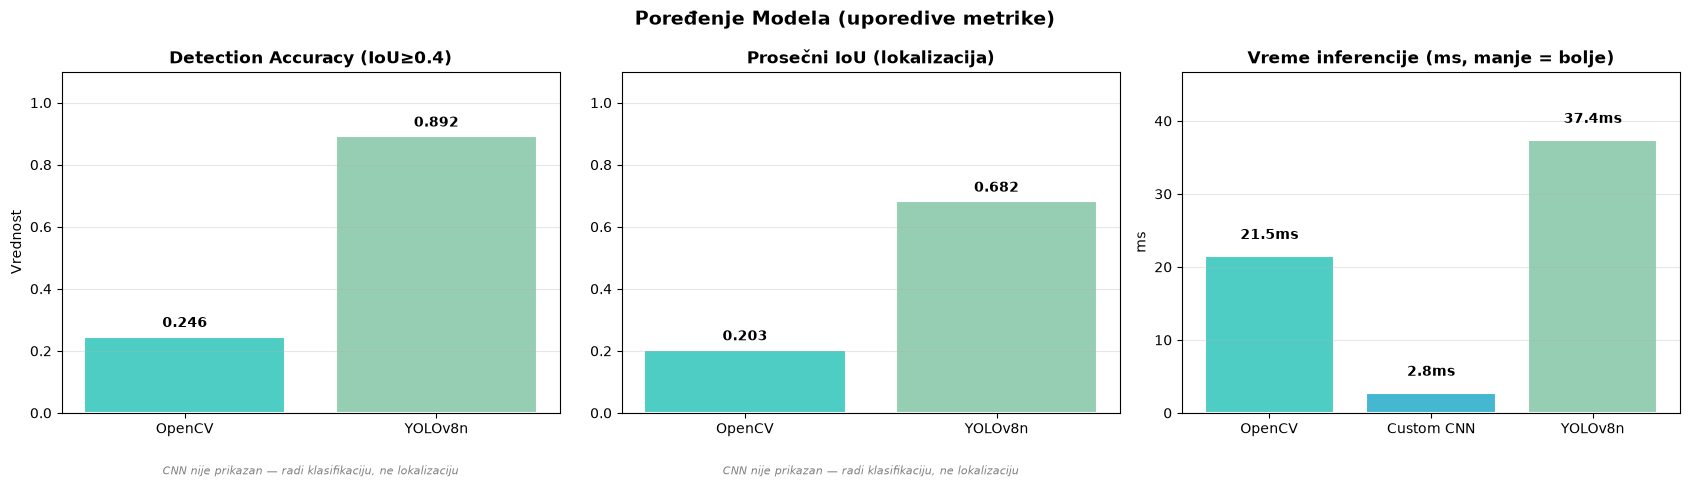

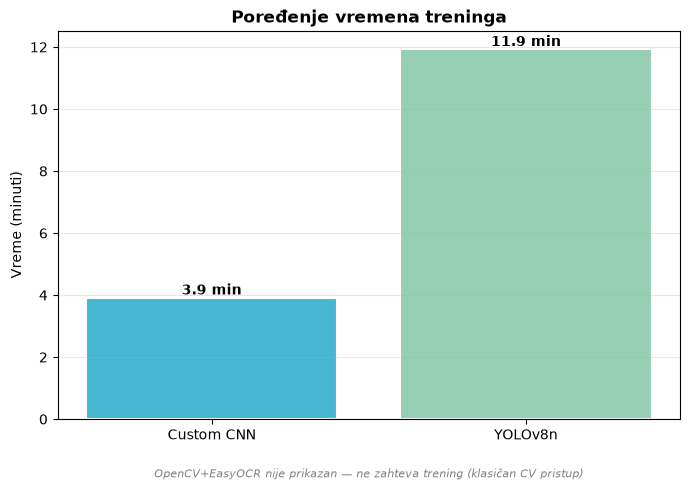

In [36]:
# ============================================================
#  Vizualizacija poređenja — samo uporedive metrike po panelu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Poređenje Modela (uporedive metrike)', fontsize=14, fontweight='bold')

models_det = ['OpenCV', 'YOLOv8n']   # samo modeli sa lokalizacijom
colors_det = ['#4ECDC4', '#96CEB4']

models_all = ['OpenCV', 'Custom CNN', 'YOLOv8n']
colors_all = ['#4ECDC4', '#45B7D1', '#96CEB4']

# --- Panel 1: Detection Accuracy (IoU >= 0.4) — samo OpenCV i YOLO ---
det_vals = [opencv_accuracy, yolo_detection_accuracy]
bars1 = axes[0].bar(models_det, det_vals, color=colors_det, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Detection Accuracy (IoU≥0.4)', fontweight='bold')
axes[0].set_ylabel('Vrednost')
for bar, val in zip(bars1, det_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[0].text(0.5, -0.18, 'CNN nije prikazan — radi klasifikaciju, ne lokalizaciju',
             transform=axes[0].transAxes, ha='center', fontsize=8, style='italic', color='gray')
axes[0].grid(True, alpha=0.3, axis='y')

# --- Panel 2: Prosečni IoU — samo OpenCV i YOLO ---
iou_vals = [opencv_mean_iou, yolo_mean_iou_matched]
bars2 = axes[1].bar(models_det, iou_vals, color=colors_det, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Prosečni IoU (lokalizacija)', fontweight='bold')
for bar, val in zip(bars2, iou_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
axes[1].text(0.5, -0.18, 'CNN nije prikazan — radi klasifikaciju, ne lokalizaciju',
             transform=axes[1].transAxes, ha='center', fontsize=8, style='italic', color='gray')
axes[1].grid(True, alpha=0.3, axis='y')

# --- Panel 3: Vreme inferencije — sva 3 modela (ovo JESTE uporedivo) ---
time_vals = [opencv_avg_time*1000, cnn_avg_time*1000, yolo_avg_time*1000]
bars3 = axes[2].bar(models_all, time_vals, color=colors_all, edgecolor='white', linewidth=1.5)
axes[2].set_title('Vreme inferencije (ms, manje = bolje)', fontweight='bold')
axes[2].set_ylabel('ms')
axes[2].set_ylim(0, max(time_vals) * 1.25)  # prostor iznad barova za tekst

for bar, val in zip(bars3, time_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(time_vals)*0.05,
                 f'{val:.1f}ms', ha='center', va='bottom', fontweight='bold')

axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()   

# ============================================================
#  Poređenje vremena treninga
# ============================================================
train_models = ['Custom CNN', 'YOLOv8n']
train_times_min = [cnn_train_time / 60, yolo_train_time / 60]
colors_train = ['#45B7D1', '#96CEB4']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(train_models, train_times_min, color=colors_train, edgecolor='white', linewidth=1.5)

ax.set_ylabel('Vreme (minuti)')
ax.set_title('Poređenje vremena treninga', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, train_times_min):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{val:.1f} min', ha='center', va='bottom', fontweight='bold')

ax.text(0.5, -0.15, 'OpenCV+EasyOCR nije prikazan — ne zahteva trening (klasičan CV pristup)',
        transform=ax.transAxes, ha='center', fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.show()

---
#  9. Zaključci i Diskusija

## 9.1 Analiza po modelu

### Model 1: OpenCV + EasyOCR
- **Prednosti:** Nije potreban trening, pruža OCR sposobnost (čitanje teksta tablice), lako se razume i debaguje
- **Nedostaci:** Osetljiv na osvetljenje i ugao, loše radi sa nestandardnim tablicama, mnogo hiper-parametara za ručno podešavanje
- **Preporučeno za:** Brze prototiope, situacije bez GPU-a, kada je potreban i OCR

### Model 2: Custom CNN
- **Prednosti:** Uči direktno iz podataka, relativno malo parametara, razumljiva arhitektura
- **Nedostaci:** Radi binarnu klasifikaciju (ne detekciju), potreban je balansiran dataset
- **Preporučeno za:** Razumevanje osnova deep learninga, situacije bez potrebe za tačnom lokalizacijom

### Model 3: YOLOv8n
- **Prednosti:** Najviša tačnost detekcije, brza inferencija, end-to-end daje i lokalizaciju
- **Nedostaci:** Zahteva GPU za trening, teže za razumeti arhitekturom
- **Preporučeno za:** Produkcijske sisteme, kada je tačnost kritična

In [28]:
# ============================================================
#  Finalni sumarni grafikon
# ============================================================
print("\n" + "="*60)
print("                    FINALNI IZVEŠTAJ")
print("="*60)
print("\nTema: Očitavanje i prepoznavanje registarskih tablica")
print(f"Dataset: andrewmvd/car-plate-detection ({len(unique_images)} slika)")
print("\nRezultati:")
print(f"  Model 1 (OpenCV+EasyOCR): IoU = {opencv_mean_iou:.3f}, Det.Rate = {opencv_accuracy:.3f}")
print(f"  Model 2 (Custom CNN):     Acc = {cnn_test_acc:.3f}, F1 = {f1_score(cnn_labels, cnn_preds):.3f}")
print(f"  Model 3 (YOLOv8n):        IoU = {yolo_mean_iou_matched:.3f}, Det.Rate = {yolo_detection_accuracy:.3f} (mAP@0.5 = {yolo_map50:.3f})")
print("="*60)


                    FINALNI IZVEŠTAJ

Tema: Očitavanje i prepoznavanje registarskih tablica
Dataset: andrewmvd/car-plate-detection (433 slika)

Rezultati:
  Model 1 (OpenCV+EasyOCR): IoU = 0.203, Det.Rate = 0.246
  Model 2 (Custom CNN):     Acc = 0.970, F1 = 0.970
  Model 3 (YOLOv8n):        IoU = 0.682, Det.Rate = 0.892 (mAP@0.5 = 0.905)
